In [1]:
import gpflow as gpf
import tensorflow as tf
import numpy as np
import sys
sys.path.append("../..")
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from gpflow.covariances.dispatch import Kuf, Kuu
from gpflow.utilities import to_default_float, assert_params_false, add_likelihood_noise_cov
from gpflow.config import default_jitter, default_float
from gpflow.utilities import to_default_float
from gpflow.models.util import InducingPointsLike, data_input_to_tensor, inducingpoint_wrapper
from gpflow.inducing_variables import InducingPoints
from typing import NamedTuple


from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50, "maxiter": 200})
    plt.plot(res["loss_history"])
    plt.show()

2026-06-11 11:00:38.313876: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-11 11:00:38.315297: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-11 11:00:38.341157: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-11 11:00:38.341794: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-11 11:00:38.945602: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

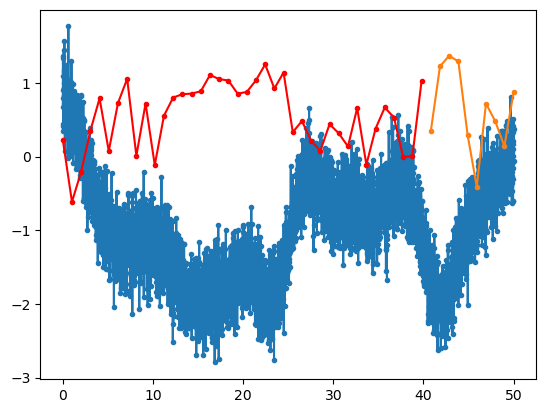

In [2]:
k = gpf.kernels.RBF(lengthscales=3, variance=1) #+ gpf.kernels.Linear(0.001)
NDP = 5000
Xall = np.linspace(0, 50, NDP)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, NDP, 1)
ind_2 = np.linspace(0, NDP-1, 50).astype(int)
TEST_INDEX = int(0.8*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1] #+ np.random.multivariate_normal(np.zeros_like(Xall[ind_1]), gpf.kernels.Cosine(variance=1, lengthscales=10)(Xall[ind_1].reshape(-1, 1)))
X2 = Xall[ind_train]
y2 = Yall[ind_train]

X2 = X2 - X2[0]
scalar = -0.5
y2 = (scalar * y2 + np.random.normal(0, 0.3, len(y2))).reshape(-1, 1)
Xtest, ytest = Xall[ind_test], Yall[ind_test]
ytest =  (ytest * scalar + np.random.normal(0, 0.3, len(ytest))).reshape(-1, 1)
ytest = ytest
Xtest = Xtest

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.3, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".", color="red")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

In [ ]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50
ivs = np.linspace(0, max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value         │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ Spar

In [ ]:
w = m.kernel.kernels[1].W.numpy()
print(w @ w.T)

[[109.18561168 -68.09351338]
 [-68.09351338  42.46646141]]


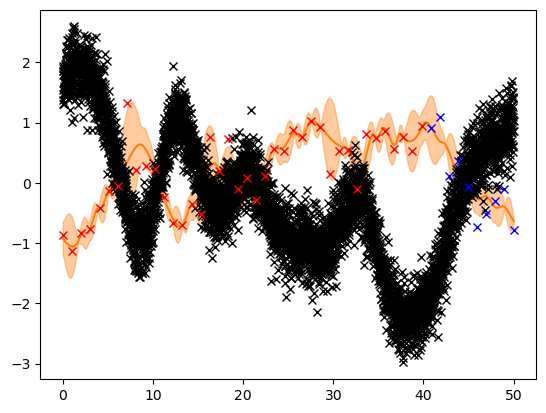

0.08264536508738521

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.expensive_predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
#plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

2026-06-11 10:57:01.389828: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-06-11 10:57:01.426640: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

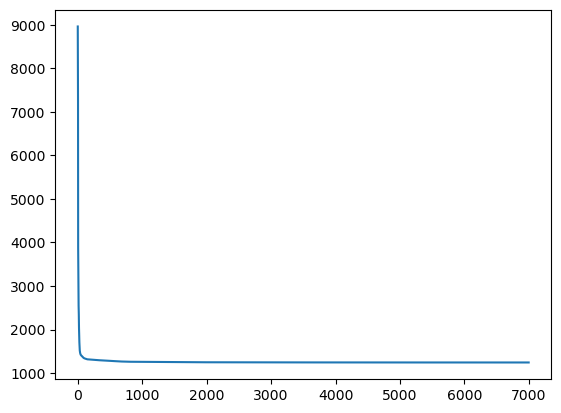

In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)

ivs = np.linspace(0, max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((int(len(ivs)/2),1 )), np.zeros((int(len(ivs)/2), 1))))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)

# fit the covariance function parameters
res = gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    track_loss_history=True
)
plt.plot(res['loss_history'])

In [ ]:
w = m.kernel.kernels[1].W.numpy()
print(w @ w.T)

[[116.35185357 -56.54926395]
 [-56.54926395  27.4840422 ]]


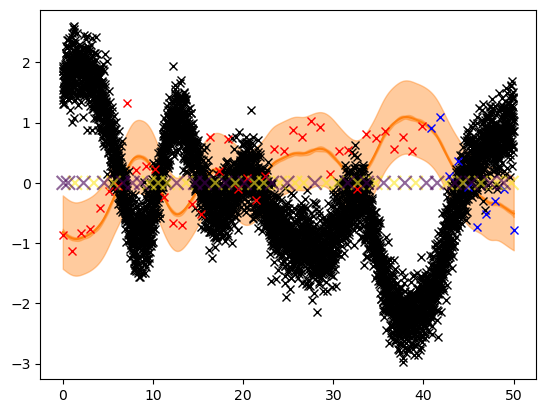

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 0.022346062071662363                                 │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()         

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

svgp_mse = mean_squared_error(ytest, fmean_tst)
svgp_mse

gpf.utilities.print_summary(m)
print(svgp_mse)